In [1]:
#!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.5/145.5 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.0
    Uninstalling joblib-1.5.0:
      Successfully uninstalled joblib-1.5.0


In [31]:
import numpy as np
import pandas as pd
import random
import shap
from time import time
from tqdm import tqdm
import joblib
import os
from sklearn.preprocessing import MinMaxScaler, StandardScaler,LabelEncoder
from sklearn.metrics import roc_curve, auc,accuracy_score,f1_score,roc_auc_score,classification_report,confusion_matrix,f1_score
from scipy.io.arff import loadarff
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from sktime.datasets import load_from_tsfile_to_dataframe
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical


import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, GRU, LSTM, Flatten, MaxPooling1D,Dropout,Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.python.keras.callbacks import Callback, EarlyStopping
from tensorflow.keras.regularizers import l2


In [4]:
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(20)

In [6]:
path_file = "/content/FingerMovements/"

In [7]:
train_path="/content/FingerMovements/FingerMovements_TRAIN.ts"
test_path="/content/FingerMovements/FingerMovements_TEST.ts"

def load_ts_file_to_numpy(path):
    X_df, y = load_from_tsfile_to_dataframe(path)
    print(X_df.columns)
    # Convert sktime format → numpy (samples, timesteps, channels)
    X_np = np.stack([np.stack([dim.to_numpy() for dim in row], axis=1) for _, row in X_df.iterrows()])
    return X_np, np.array(y)

In [8]:
X_train, y_train = load_ts_file_to_numpy(train_path)
X_test, y_test = load_ts_file_to_numpy(test_path)

print(X_train.shape)

Index(['dim_0', 'dim_1', 'dim_2', 'dim_3', 'dim_4', 'dim_5', 'dim_6', 'dim_7',
       'dim_8', 'dim_9', 'dim_10', 'dim_11', 'dim_12', 'dim_13', 'dim_14',
       'dim_15', 'dim_16', 'dim_17', 'dim_18', 'dim_19', 'dim_20', 'dim_21',
       'dim_22', 'dim_23', 'dim_24', 'dim_25', 'dim_26', 'dim_27'],
      dtype='object')
Index(['dim_0', 'dim_1', 'dim_2', 'dim_3', 'dim_4', 'dim_5', 'dim_6', 'dim_7',
       'dim_8', 'dim_9', 'dim_10', 'dim_11', 'dim_12', 'dim_13', 'dim_14',
       'dim_15', 'dim_16', 'dim_17', 'dim_18', 'dim_19', 'dim_20', 'dim_21',
       'dim_22', 'dim_23', 'dim_24', 'dim_25', 'dim_26', 'dim_27'],
      dtype='object')
(316, 50, 28)


In [9]:
print(y_train.shape)

(316,)


In [10]:
X_train

array([[[ 41.8,  55.2,  -8.6, ...,  16.9,  42.2,  13. ],
        [ 44.8,  53.8,  -3.6, ...,  24.5,  35. ,  26.6],
        [ 47.1,  59.9,  14.4, ...,  24.5,  41.7,  52.5],
        ...,
        [ 69.8,  17.5,  23.3, ...,  51.9,  51.5,  -3.5],
        [ 72.6,  28. ,  35.9, ...,  59.6,  58.5,  -3.2],
        [ 76.1,  12.1,  23.2, ...,  57.3,  46.9,  -2.6]],

       [[132. ,  99.7,  18.7, ..., -11.2, -21.7, -41.3],
        [137. ,  95.8,   0.8, ..., -11.6, -21.1, -40.2],
        [148. ,  99.5,  20. , ..., -13.8, -23.6, -33.3],
        ...,
        [ 78.1, -39.9,   0.9, ..., -31.9, -57.8, -51.1],
        [ 90.5, -10.2,  31.6, ..., -19.9, -44.6, -45.4],
        [ 85.7, -37.4,   7.3, ..., -25.7, -45.6, -42.5]],

       [[ 69.4,  67.8,   9.9, ...,  20.9,  14.1,   3.6],
        [ 57. ,  49. , -12.4, ...,  20.5,   7.9,  11. ],
        [ 76.4,  62.1,  18.7, ...,  30.1,   6.3,  14. ],
        ...,
        [ 55.6, -16.6,  18.7, ...,  16.6,   7.6,   2.2],
        [ 67.7,  12.2,  55.4, ...,  14. ,  12

In [11]:
print(np.unique(y_train))

['left' 'right']


In [12]:
#encode lables
le = LabelEncoder()
y_train_int = le.fit_transform(y_train)  # e.g., left=0, right=1
y_test_int = le.transform(y_test)

In [13]:
unique, counts = np.unique(y_train_int, return_counts=True)
class_distribution = dict(zip(unique, counts))
print("Class distribution in training data:", class_distribution)

unique, counts = np.unique(y_test_int, return_counts=True)
class_distribution = dict(zip(unique, counts))
print("Class distribution in test data:", class_distribution)


Class distribution in training data: {np.int64(0): np.int64(159), np.int64(1): np.int64(157)}
Class distribution in test data: {np.int64(0): np.int64(49), np.int64(1): np.int64(51)}


In [14]:
#normalize per channel
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [15]:
print(X_train.shape)

(316, 50, 28)


In [16]:
#balance the weights of the class labels
cw = class_weight.compute_class_weight('balanced', classes=np.array([0,1]), y=y_train_int)
class_weights = dict(enumerate(cw))
print(class_weights)

{0: np.float64(0.9937106918238994), 1: np.float64(1.0063694267515924)}


In [55]:
model = Sequential([
    LSTM(64, kernel_regularizer=l2(0.01),
         dropout=0.5,        # Dropout on input
         recurrent_dropout=0.3,  # Dropout on the recurrent connections
         input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.5),               # Dropout after LSTM output
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.fit(X_train, y_train_int, epochs=100, batch_size=32,
          validation_split=0.2, callbacks=[early_stop])

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 346ms/step - accuracy: 0.4726 - loss: 1.2328 - val_accuracy: 0.5000 - val_loss: 1.1597
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.4985 - loss: 1.1873 - val_accuracy: 0.4219 - val_loss: 1.1310
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.5512 - loss: 1.1274 - val_accuracy: 0.4688 - val_loss: 1.1063
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5308 - loss: 1.1066 - val_accuracy: 0.4375 - val_loss: 1.0777
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5763 - loss: 1.0393 - val_accuracy: 0.4688 - val_loss: 1.0448
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.5619 - loss: 1.0491 - val_accuracy: 0.4844 - val_loss: 1.0149
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.5699 - loss: 1.0051 - val_accuracy: 0.4688 - val_loss: 0.9876
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step - accuracy: 0.5235 - loss: 0.9805 - val_accuracy: 0.5469 - val_loss: 0.9

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.5051 - loss: 0.7799 - val_accuracy: 0.5781 - val_loss: 0.7468
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5178 - loss: 0.7738 - val_accuracy: 0.5781 - val_loss: 0.7469
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.5699 - loss: 0.7507 - val_accuracy: 0.5625 - val_loss: 0.7413
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.5800 - loss: 0.7662 - val_accuracy: 0.6094 - val_loss: 0.7406
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.5178 - loss: 0.7529 - val_accuracy: 0.5938 - val_loss: 0.7361
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.5732 - loss: 0.7477 - val_accuracy: 0.5938 - val_loss: 0.7370
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step - accuracy: 0.5840 - loss: 0.7260 - val_accuracy: 0.6094 - val_loss: 0.7376
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.5272 - loss: 0.7551 - val_accuracy: 0.5781 - v

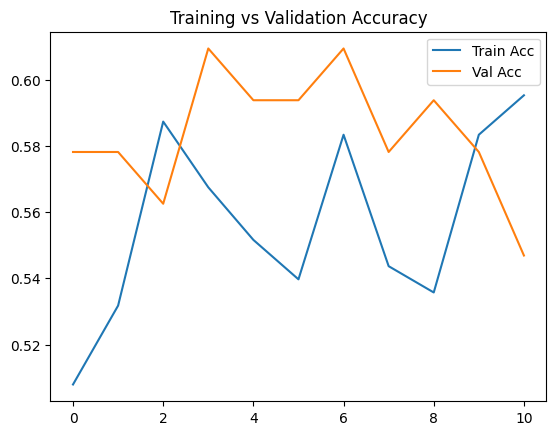

In [56]:
#plot the train and validation scores
history = model.fit(X_train, y_train_int, epochs=100, batch_size=32,
          validation_split=0.2, callbacks=[early_stop])
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [19]:
#saving the history file
# history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

# # Save only the .history dict
# with open(path_file + 'history.pkl', 'wb') as f:
#     pickle.dump(history.history, f)

In [57]:
#evaluate model test data
loss, acc = model.evaluate(X_train, y_train_int)
print(f"Train Accuracy: {acc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6140 - loss: 0.7171
Train Accuracy: 0.6044


In [58]:
#joblib.dump(model,path_file+"lstm_fingermovement_model3.pkl")

['/content/FingerMovements/lstm_fingermovement_model3.pkl']

In [23]:
#if generated model is not better then use the presaved model
model = joblib.load(path_file+"lstm_fingermovement_model2.pkl")

In [24]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,621 (279.77 KB)

 Trainable params: 23,873 (93.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 47,748 (186.52 KB)

In [25]:
#evaluate model train data
loss, acc = model.evaluate(X_train, y_train_int)
print(f"Train Accuracy: {acc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5963 - loss: 0.7212
Train Accuracy: 0.6171


In [26]:
#evaluate model test data
loss, acc = model.evaluate(X_test, y_test_int)
print(f"Test Accuracy: {acc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5836 - loss: 0.7746
Test Accuracy: 0.6100


In [27]:
#predict the target labels
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test_int, y_pred))
print(confusion_matrix(y_test_int, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step
              precision    recall  f1-score   support

           0       0.61      0.57      0.59        49
           1       0.61      0.65      0.63        51

    accuracy                           0.61       100
   macro avg       0.61      0.61      0.61       100
weighted avg       0.61      0.61      0.61       100

[[28 21]
 [18 33]]


In [28]:
#Find appropriate threshold
probs = model.predict(X_test)
for t in np.arange(0.3,0.7,0.05):
    preds = (probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test_int, preds))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.02      0.04        49
           1       0.52      1.00      0.68        51

    accuracy                           0.52       100
   macro avg       0.76      0.51      0.36       100
weighted avg       0.75      0.52      0.37       100


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.67      0.04      0.08        49
           1       0.52      0.98      0.68        51

    accuracy                           0.52       100
   macro avg       0.59      0.51      0.38       100
weighted avg       0.59      0.52      0.38       100


Threshold: 0.39999999999999997
              precision    recall  f1-score   support

           0       0.22      0.04      0.07        49
           1       0.48      0.86      0.62        51

    accuracy                           0.46       100
   macro avg       0.35  

In [29]:
#default threshold gives best model performance
thresh = 0.5
y_pred = (model.predict(X_test) > thresh).astype(int)
print(classification_report(y_test_int, y_pred))
print(confusion_matrix(y_test_int, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
              precision    recall  f1-score   support

           0       0.61      0.57      0.59        49
           1       0.61      0.65      0.63        51

    accuracy                           0.61       100
   macro avg       0.61      0.61      0.61       100
weighted avg       0.61      0.61      0.61       100

[[28 21]
 [18 33]]


In [32]:
##check model performance
print("test accuracy",accuracy_score(y_test_int, y_pred))
print("test ROC",roc_auc_score(y_test_int, y_pred))
print("test F1 Score",f1_score(y_test_int, y_pred))

test accuracy 0.61
test ROC 0.6092436974789915
test F1 Score 0.6285714285714286


In [33]:
def find_one_correct_and_one_wrong(model, X_test, y_test_enc):
    """
    Find one correctly and one incorrectly predicted instance.

    Returns:
    - correct_idx: index of a correct prediction
    - wrong_idx: index of a wrong prediction
    """
    preds = model.predict(X_test)
    pred_classes = (preds > thresh).astype(int).flatten()  # Convert to 0 or 1
    true_classes = y_test_int.copy()

    correct_idx = None
    wrong_idx = None

    for i, (p, t) in enumerate(zip(pred_classes, true_classes)):
        if correct_idx is None and p == t:
            correct_idx = i
        if wrong_idx is None and p != t:
            wrong_idx = i
        if correct_idx is not None and wrong_idx is not None:
            break

    return correct_idx, wrong_idx


In [34]:
# Find one correct and one wrong prediction
correct_idx, incorrect_idx = find_one_correct_and_one_wrong(model, X_test, y_test_int)

print(f"Correct prediction at index: {correct_idx}")
print(f"Wrong prediction at index: {incorrect_idx}")

# Prepare input tensors
input_tensor_correct = tf.convert_to_tensor(X_test[correct_idx:correct_idx+1], dtype=tf.float32)
input_tensor_wrong   = tf.convert_to_tensor(X_test[incorrect_idx:incorrect_idx+1], dtype=tf.float32)

# === Correct prediction instance ===
correct_preds = model.predict(input_tensor_correct)
true_class_correct = y_test_int[correct_idx]
pred_class_correct = int(correct_preds[0][0] > thresh)
confidence_correct = correct_preds[0][0]

print(f"Actual class for instance '{correct_idx}': {true_class_correct}")
print(f"Predicted class: {pred_class_correct}")
print(f"Confidence score: {confidence_correct:.4f}")

# === Incorrect prediction instance ===
incorrect_preds = model.predict(input_tensor_wrong)
true_class_incorrect = y_test_int[incorrect_idx]
pred_class_incorrect = int(incorrect_preds[0][0] >thresh)
confidence_incorrect = incorrect_preds[0][0]

print(f"\nActual class for instance '{incorrect_idx}': {true_class_incorrect}")
print(f"Predicted class: {pred_class_incorrect}")
print(f"Confidence score: {confidence_incorrect:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Correct prediction at index: 0
Wrong prediction at index: 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Actual class for instance '0': 1
Predicted class: 1
Confidence score: 0.6136
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step

Actual class for instance '3': 0
Predicted class: 1
Confidence score: 0.6281


In [35]:
################ INTEGRATED GRADIENTS ####################

In [36]:
@tf.function
def interpolate_inputs(baseline, input, alphas):
    return baseline + alphas * (input - baseline)

def integrated_gradients(model, input_tensor, baseline=None, steps=50):
    if baseline is None:
        baseline = tf.zeros_like(input_tensor)
    batch_size, timesteps, features = input_tensor.shape

    # Create alphas for interpolation
    alphas = tf.linspace(0.0, 1.0, steps + 1)  # shape (steps+1,)
    alphas = tf.reshape(alphas, (steps + 1, 1, 1, 1))  # shape (steps+1, 1, 1, 1)

    # Expand input/baseline: (1, batch, time, features)
    input_expanded = tf.expand_dims(input_tensor, axis=0)
    baseline_expanded = tf.expand_dims(baseline, axis=0)

    # Interpolate: (steps+1, batch, time, features)
    interpolated = baseline_expanded + alphas * (input_expanded - baseline_expanded)

    # Reshape for batch prediction: (steps+1)*batch, time, features
    interpolated_reshaped = tf.reshape(interpolated, [(steps + 1) * batch_size, timesteps, features])

    with tf.GradientTape() as tape:
        tape.watch(interpolated_reshaped)
        preds = model(interpolated_reshaped)

        preds_batch = model(input_tensor)
        target_class_idx = tf.argmax(preds_batch, axis=1)
        target_class_idx = tf.cast(target_class_idx, tf.int32)

        # Repeat once per interpolation step
        target_class_idx = tf.repeat(target_class_idx, repeats=steps + 1)

        # Tile to match the long interpolated input shape
        target = tf.gather(preds, target_class_idx, axis=1, batch_dims=1)

    # Compute gradients
    grads = tape.gradient(target, interpolated_reshaped)
    grads = tf.reshape(grads, [steps + 1, batch_size, timesteps, features])

    # Average across interpolation steps (exclude endpoint)
    avg_grads = tf.reduce_mean(grads[:-1], axis=0)

    # Final IG attribution
    integrated_grad = (input_tensor - baseline) * avg_grads

    return integrated_grad.numpy()

In [37]:
def plot_ig_with_overlay(
    ig_attribs,
    input_tensor,
    top_n=5,
    instance_index=0,
    use_abs=True,
    show_avg=True,
    show_raw=True,
    show_cumulative=True,
    output_path=None,
    feature_names=None
):
    """
    Plot Integrated Gradients for top-N features, with optional raw input and cumulative IG overlay.

    Parameters:
    - ig_attribs: np.ndarray, shape (1, time_steps, features)
    - input_tensor: np.ndarray, shape (1, time_steps, features)
    - top_n: int, number of top features to show
    - use_abs: bool, rank features by absolute contribution
    - show_avg: bool, overlay average IG
    - show_raw: bool, overlay raw input values
    - show_cumulative: bool, show cumulative IG curves
    - output_path: str or None, path to save the plot
    - feature_names: list of feature names (optional)

    Returns:
    - top_features: list of top-N feature indices
    """

    ig_instance = ig_attribs[0]        # (time_steps, features)
    input_instance = input_tensor[0]  # (time_steps, features)

    contrib = np.sum(np.abs(ig_instance), axis=0) if use_abs else np.sum(ig_instance, axis=0)
    top_features = np.argsort(contrib)[::-1][:top_n]

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))

    for i in top_features:
        label = feature_names[i] if feature_names else f'Feature {i}'
        ax.plot(ig_instance[:, i], label=f"IG - {label}")

        if show_raw:
            ax.plot(input_instance[:, i], '--', label=f"Input - {label}", alpha=0.5)

        if show_cumulative:
            cum_ig = np.cumsum(ig_instance[:, i])
            ax.plot(cum_ig, ':', label=f"Cumulative IG - {label}", alpha=0.6)

    if show_avg:
        avg = ig_instance.mean(axis=1)
        ax.plot(avg, color='black', linewidth=2, label='Avg IG Across Features')

    ax.set_title(f"Integrated Gradients - Instance {instance_index} (Top {top_n})")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Attribution")
    ax.grid(True)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path)
        print(f"Plot saved to: {output_path}")
    plt.show()

    return top_features


ACTUAL CLASS - 1
PREDICTED CLASS - 1
Plot saved to: /content/FingerMovements/ig_overlay_instance0-correct_pred.png


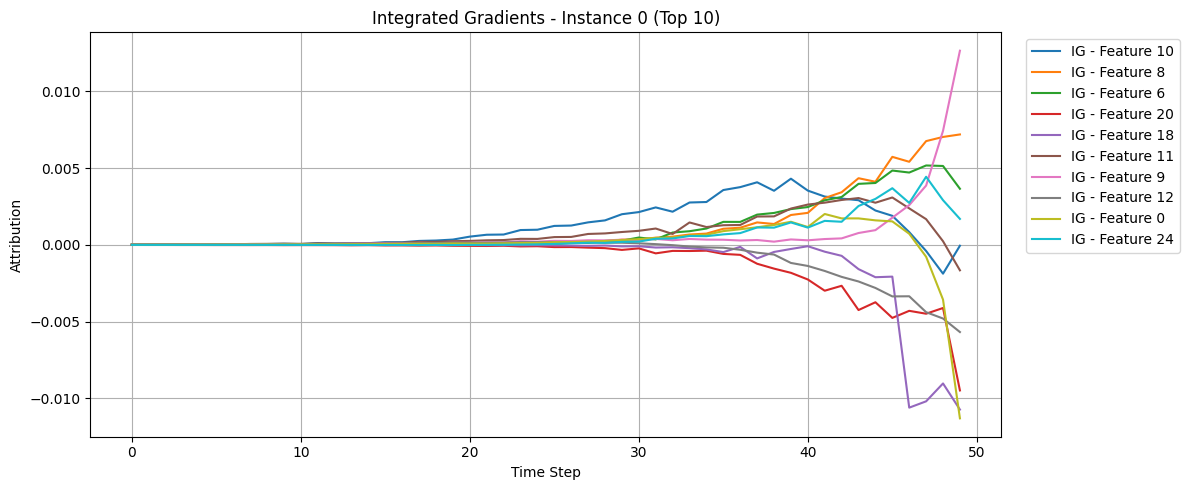

In [38]:
print(f"ACTUAL CLASS - {true_class_correct}")
print(f"PREDICTED CLASS - {pred_class_correct}")
ig_attribs = integrated_gradients(model, input_tensor_correct)
top_feats = plot_ig_with_overlay(
    ig_attribs=ig_attribs,
    input_tensor=input_tensor_correct.numpy(),  # if it's a TF tensor
    top_n=10,
    show_avg=False,
    show_raw=False,
    show_cumulative=False,
    instance_index=correct_idx,
    output_path=path_file + f"ig_overlay_instance{correct_idx}-correct_pred.png",
    #feature_names=feature_names  # optional
)

In [39]:
#Each line shows how much a specific feature’s cumulative influence grows or declines over time toward the model's final prediction.
#Positive slope / positive attribution : That feature contributes toward predicting class 1 (your predicted class here).
#Negative slope / negative attribution:That feature is pushing against the final class prediction (toward class 0).
#The most important time window for decision making is likely between time steps 30 to 50, where attribution grows or drops the fastest.

ACTUAL CLASS - 0
PREDICTED CLASS - 1
Plot saved to: /content/FingerMovements/ig_overlay_instance3-incorrect_pred.png


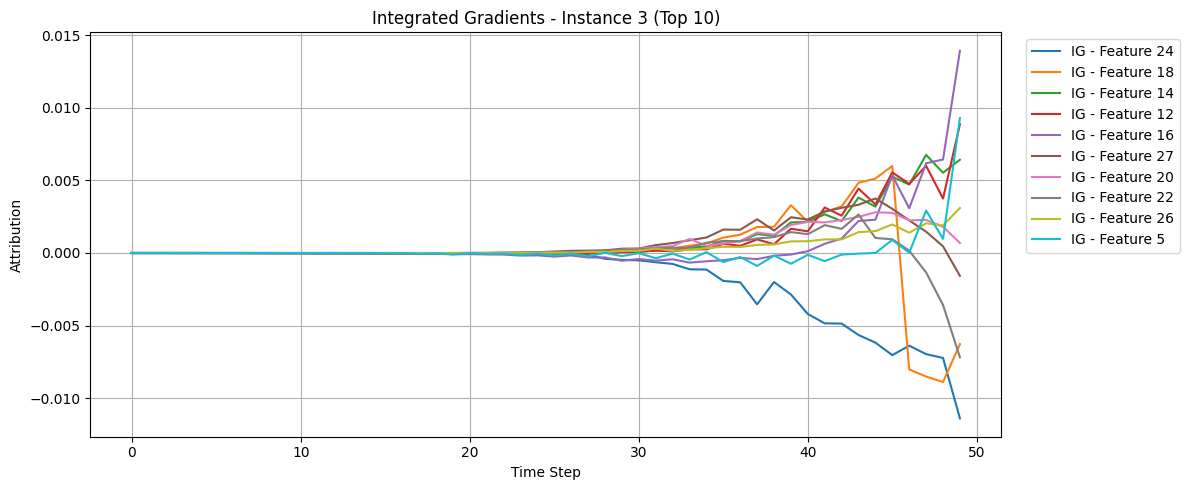

In [40]:
print(f"ACTUAL CLASS - {true_class_incorrect}")
print(f"PREDICTED CLASS - {pred_class_incorrect}")
ig_attribs = integrated_gradients(model, input_tensor_wrong)
top_feats = plot_ig_with_overlay(
    ig_attribs=ig_attribs,
    input_tensor=input_tensor_wrong.numpy(),  # if it's a TF tensor
    top_n=10,
    show_avg=False,
    show_raw=False,
    show_cumulative=False,
    instance_index=incorrect_idx,
    output_path=path_file + f"ig_overlay_instance{incorrect_idx}-incorrect_pred.png",
    #feature_names=feature_names  # optional
)

In [41]:
# Higher |IG value| = stronger contribution at that time step

# Doesn't matter if it's + or – unless you're interpreting direction
#Positive IG → increases the model's prediction toward the predicted class
#Most IG activity is clustered near the end of the time series (t=40–50) - The model relies most on late-sequence signals.

In [42]:
def plot_top_ig_features_by_class(ig_values, preds, top_n=10, class_names=("Class 0", "Class 1")):
    """
    Plot top N most important features per predicted class based on Integrated Gradients.

    Parameters:
    - ig_values: np.array of shape (samples, timesteps, features)
    - preds: predicted class labels, shape (samples,)
    - top_n: number of top features to show per class
    - class_names: tuple of class names for plot titles
    """

    # Sanity checks
    assert len(ig_values.shape) == 3, "IG values should be 3D: (samples, time steps, features)"
    assert ig_values.shape[0] == len(preds), "Mismatch in number of samples and predictions"

    # Compute mean absolute IG values over time and samples for each class
    avg_ig_class0 = np.mean(np.abs(ig_values[preds == 0]), axis=(0, 1))
    avg_ig_class1 = np.mean(np.abs(ig_values[preds == 1]), axis=(0, 1))

    # Create DataFrames for ranking
    df_class0 = pd.DataFrame({
        f'Feature ({class_names[0]})': [f'Feature {i}' for i in np.argsort(avg_ig_class0)[::-1][:top_n]],
        f'Mean IG ({class_names[0]})': np.sort(avg_ig_class0)[::-1][:top_n]
    })

    df_class1 = pd.DataFrame({
        f'Feature ({class_names[1]})': [f'Feature {i}' for i in np.argsort(avg_ig_class1)[::-1][:top_n]],
        f'Mean IG ({class_names[1]})': np.sort(avg_ig_class1)[::-1][:top_n]
    })
    # Combine tables
    combined_df = pd.concat([df_class0, df_class1], axis=1)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    axes[0].barh(df_class0[f'Feature ({class_names[0]})'][::-1],
                 df_class0[f'Mean IG ({class_names[0]})'][::-1], color="skyblue")
    axes[0].set_title(f"Top {top_n} Features for {class_names[0]}")
    axes[0].set_xlabel("Mean IG Attribution")
    axes[0].grid(True)

    axes[1].barh(df_class1[f'Feature ({class_names[1]})'][::-1],
                 df_class1[f'Mean IG ({class_names[1]})'][::-1], color="salmon")
    axes[1].set_title(f"Top {top_n} Features for {class_names[1]}")
    axes[1].set_xlabel("Mean IG Attribution")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return combined_df  # optionally return the ranked table


In [43]:
preds.shape

(100, 1)

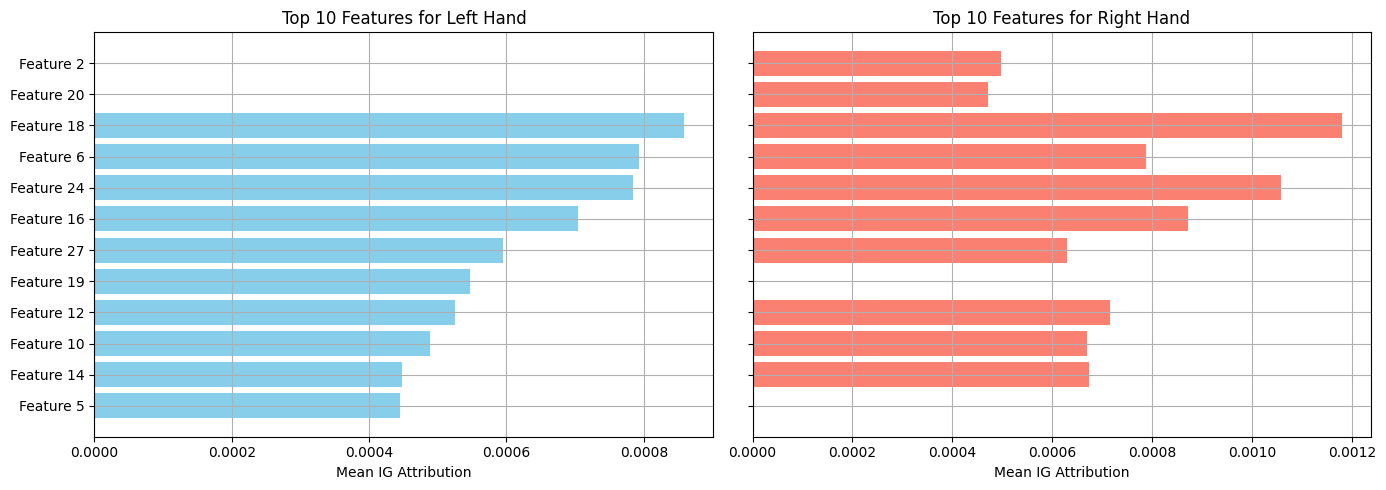

<Figure size 640x480 with 0 Axes>

In [44]:
pred_classes = (preds > thresh).astype(int).flatten()
inpu_tensor_sample = tf.convert_to_tensor(X_test[:100], dtype=tf.float32)
ig_values = integrated_gradients(model, input_tensor=inpu_tensor_sample)
ranked_df = plot_top_ig_features_by_class(ig_values, pred_classes, top_n=10, class_names=("Left Hand", "Right Hand"))
plt.savefig(path_file + "TOP N FEATURES BY CLASS.png")

In [45]:
################# SALIENCY MAPS ###############################

In [46]:

def generate_saliency_maps(model, X, max_samples=None, verbose=True):
    """
    Generate saliency map values for a batch of samples using gradients.

    Parameters:
    - model: Trained Keras model
    - X: np.ndarray, shape (n_samples, time_steps, 1)
    - max_samples: Optional[int], number of samples to process
    - verbose: bool, whether to show progress bar

    Returns:
    - saliency_map_values: np.ndarray, shape (n_samples, time_steps, 1)
    """
    if max_samples is not None:
        X = X[:max_samples]

    saliency_maps = []
    iterator = tqdm(range(len(X)), desc="Computing saliency") if verbose else range(len(X))

    for i in iterator:
        input_tensor = tf.convert_to_tensor(X[i:i+1], dtype=tf.float32)

        with tf.GradientTape() as tape:
            tape.watch(input_tensor)
            preds = model(input_tensor)
            pred_index = tf.argmax(preds[0])
            loss = preds[:, pred_index]

        grads = tape.gradient(loss, input_tensor)
        saliency = tf.abs(grads).numpy()  # shape: (1, time_steps, 1)
        #saliency = grads.numpy()
        saliency_maps.append(saliency[0])  # remove batch dim

    return np.array(saliency_maps)  # shape: (n_samples, time_steps, 1)


In [47]:
saliency_map_values = generate_saliency_maps(model, X_test,max_samples=100, verbose=False)
print(saliency_map_values.shape)

(100, 50, 28)


In [48]:
def plot_global_saliency_windows(
    saliency_map_values,
    window_size=10,
    top_n=3,
    output_path=None,
    title="Global Saliency Over Time",
    label="Global Avg Saliency",
    color="purple",
    alpha=0.3,
    show_labels=True
):
    """
    Plot global saliency over time from multivariate saliency maps.

    Parameters:
    - saliency_map_values: np.ndarray, shape (n_samples, time_steps, features)
    - window_size: int, size of each time window
    - top_n: int, number of top windows to highlight
    - output_path: str or None, where to save the plot (e.g., './global_saliency.png')
    - title: str, title for the plot
    - label: str, label for the saliency line
    - color: str, color of the line
    - alpha: float, transparency for highlighted windows
    - show_labels: bool, annotate W1, W2 on highlighted windows

    Returns:
    - global_avg_saliency: np.ndarray of shape (time_steps,)
    - top_windows: list of (start, end, score)
    """

    # Step 1: Reduce across features → (samples, time_steps)
    saliency_reduced = saliency_map_values.mean(axis=2)

    # Step 2: Average across samples → (time_steps,)
    global_avg_saliency = saliency_reduced.mean(axis=0)

    # Step 3: Extract top-N time windows
    def get_top_windows(avg_saliency, window_size=10, top_n=3):
        scores = []
        for i in range(len(avg_saliency) - window_size + 1):
            window_sum = np.sum(avg_saliency[i:i+window_size])
            scores.append((i, i + window_size - 1, window_sum))
        return sorted(scores, key=lambda x: x[2], reverse=True)[:top_n]

    top_windows = get_top_windows(global_avg_saliency, window_size, top_n)

    # Step 4: Plot
    plt.figure(figsize=(12, 4))
    plt.plot(global_avg_saliency, label=label, color=color, linewidth=2)

    for i, (start, end, _) in enumerate(top_windows):
        plt.axvspan(start, end, color=color, alpha=alpha, label="Top Window" if i == 0 else "")
        if show_labels:
            plt.text((start + end) / 2, np.max(global_avg_saliency), f"W{i+1}",
                     ha='center', fontsize=8, color='black')

    # Handle legend
    handles, labels = plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    plt.legend(unique.values(), unique.keys())

    # Labels & layout
    plt.title(title)
    plt.xlabel("Time Step")
    plt.ylabel("Avg Gradient Magnitude")
    plt.grid(True)
    plt.tight_layout()

    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path)
        print(f"Saved global saliency plot to: {output_path}")
    plt.show()

    return global_avg_saliency, top_windows


✅ Saved global saliency plot to: /content/FingerMovements/global_saliency.png


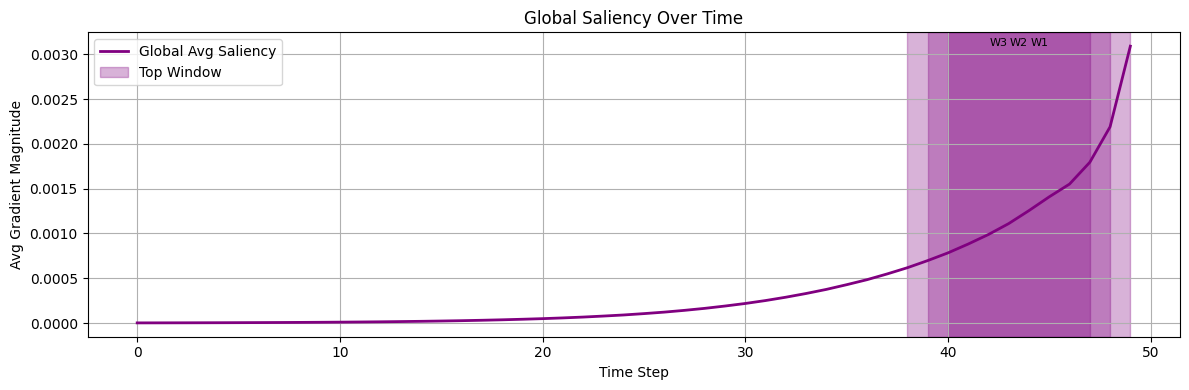

In [49]:
global_avg_saliency, top_windows = plot_global_saliency_windows(
    saliency_map_values=saliency_map_values,
    window_size=10,
    top_n=3,
    output_path=path_file + "global_saliency.png"
)

In [50]:
def plot_instance_saliency_top_features(
    saliency_2d,
    top_n=5,
    show_average=True,
    instance_index=0,
    title_prefix="Saliency Map",
    output_path=None
):
    """
    Plot top-N most important features in a local saliency map (1 instance).

    Parameters:
    - saliency_2d: np.ndarray, shape (time_steps, features)
    - top_n: int, number of top features to plot
    - show_average: bool, whether to overlay average saliency
    - instance_index: int, index of the input instance (for title)
    - title_prefix: str, prefix for plot title
    - output_path: str or None, if set, saves the plot to this path

    Returns:
    - top_features: list of top-N feature indices
    """
    time_steps, n_features = saliency_2d.shape

    # Compute total saliency per feature across all time steps
    feature_importance = saliency_2d.sum(axis=0)
    top_features = np.argsort(feature_importance)[::-1][:top_n]

    # Plot
    plt.figure(figsize=(12, 4))
    for i in top_features:
        plt.plot(saliency_2d[:, i], label=f'Feature {i}')

    if show_average:
        avg_saliency = saliency_2d.mean(axis=1)
        plt.plot(avg_saliency, label='Avg Across Features', color='black', linewidth=2)

    plt.title(f"{title_prefix} - Instance {instance_index} (Top {top_n} Features)")
    plt.xlabel("Time Step")
    plt.ylabel("Gradient Magnitude")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path)
        print(f" Saved saliency plot to: {output_path}")
    plt.show()

    return top_features


ACTUAL CLASS - 1
PREDICTED CLASS - 1
 Saved saliency plot to: /content/FingerMovements/instance_0_top_saliency-correct_preds.png


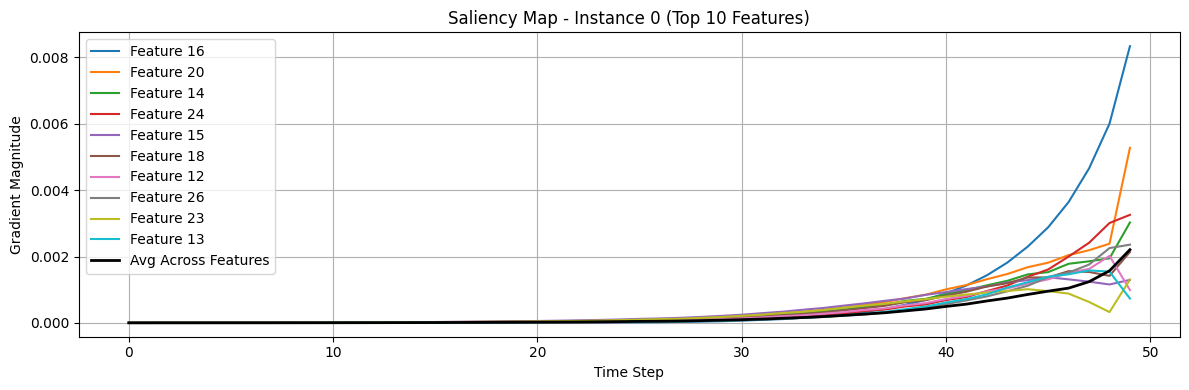

In [51]:
print(f"ACTUAL CLASS - {true_class_correct}")
print(f"PREDICTED CLASS - {pred_class_correct}")
#Compute saliency for one input instance
saliency_instance_values = generate_saliency_maps(model, input_tensor_correct, max_samples=1, verbose=False)
saliency_instance = saliency_instance_values[0]  # shape: (time_steps, features)

top_feats = plot_instance_saliency_top_features(
    saliency_2d=saliency_instance,
    top_n=10,
    show_average=True,
    instance_index=correct_idx,
    output_path=path_file + f"instance_{correct_idx}_top_saliency-correct_preds.png"
)

ACTUAL CLASS - 0
PREDICTED CLASS - 1
 Saved saliency plot to: /content/FingerMovements/instance_3_top_saliency-wrong_preds.png


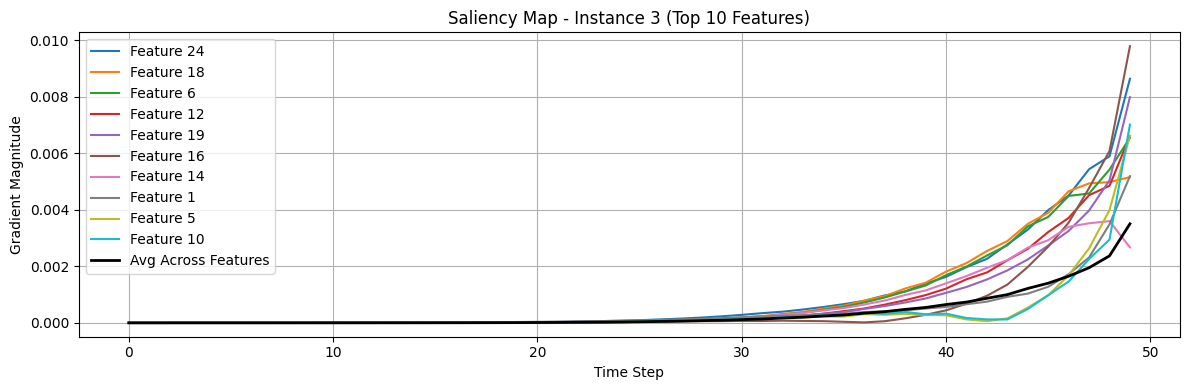

In [52]:
#SHOW SALIENCY MAP FOR THE MISCLASSIFIED INSTANCE
print(f"ACTUAL CLASS - {true_class_incorrect}")
print(f"PREDICTED CLASS - {pred_class_incorrect}")
saliency_instance_values = generate_saliency_maps(model, input_tensor_wrong, max_samples=1, verbose=False)
saliency_instance = saliency_instance_values[0]  # shape: (time_steps, features)

top_feats = plot_instance_saliency_top_features(
    saliency_2d=saliency_instance,
    top_n=10,
    show_average=True,
    instance_index=incorrect_idx,
    output_path=path_file + f"instance_{incorrect_idx}_top_saliency-wrong_preds.png"
)

In [53]:
plt.figure(figsize=(15,10))

#background data
background_data = shap.sample(X_train, 50)

# Use the actual model object and the 3D data
explainer = shap.GradientExplainer(model, background_data)

# Compute SHAP values for a sample of the test set using the original 3D data
shap_values = explainer.shap_values(X_test[:10])

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_6
Received: inputs=['Tensor(shape=(10, 50, 28))']
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_6
Received: inputs=['Tensor(shape=(50, 50, 28))']
  warnings.warn(msg)


<Figure size 1500x1000 with 0 Axes>

<ipython-input-54-0951975ef049>:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_for_plotting, x_test_flat_sample, feature_names=feature_names, plot_type="bar",show=False)


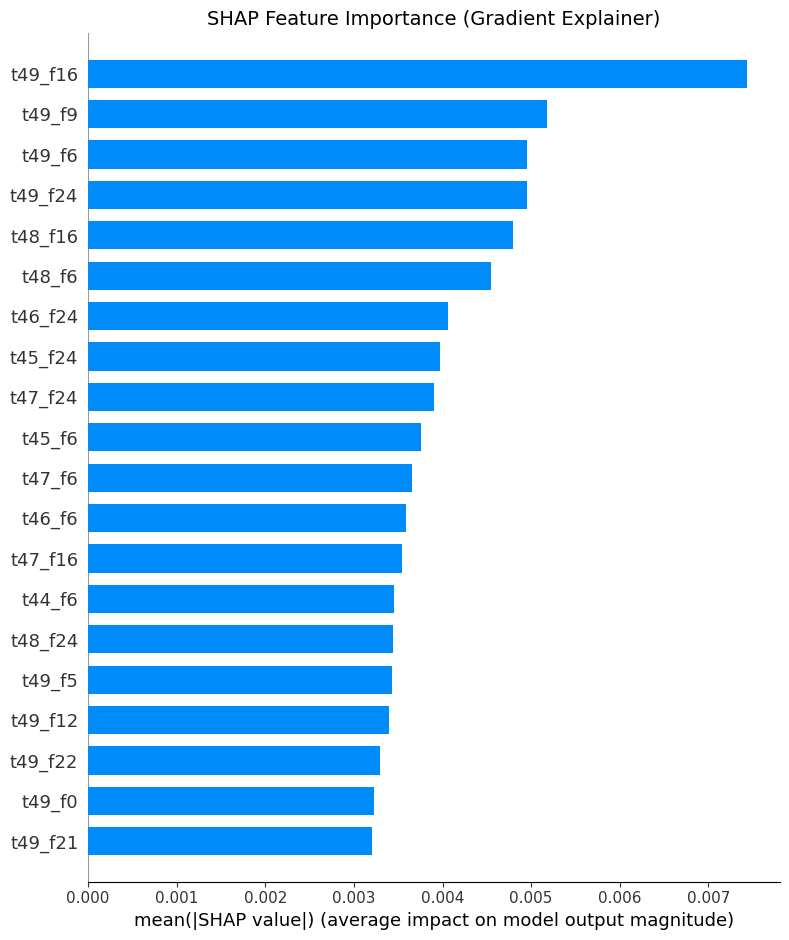

In [54]:
# Assuming shap_values is a list where the first element is the relevant attribution array

if isinstance(shap_values, list):
    shap_values_for_plotting = shap_values[0].reshape(shap_values[0].shape[0], -1)
else:
     shap_values_for_plotting = shap_values.reshape(shap_values.shape[0], -1)


# Flatten the test data sample to match the reshaped shap_values for plotting
x_test_flat_sample = X_test[:10].reshape(X_test[:10].shape[0], -1)

timesteps = X_test.shape[1]
features = X_test.shape[2]
# Create feature names based on the flattened structure (e.g., time0_feat0, time0_feat1, ...)
feature_names = [f't{t}_f{f}' for t in range(timesteps) for f in range(features)]

# Plot the summary
# Pass the reshaped shap values and the flattened test data sample
shap.summary_plot(shap_values_for_plotting, x_test_flat_sample, feature_names=feature_names, plot_type="bar",show=False)
plt.gca().set_title("SHAP Feature Importance (Gradient Explainer)", fontsize=14)
plt.savefig(path_file + "shap_summary.png")

plt.tight_layout()
plt.show()